In [140]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "taxi.csv"
OBESITY_URL = "obesity.csv"

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

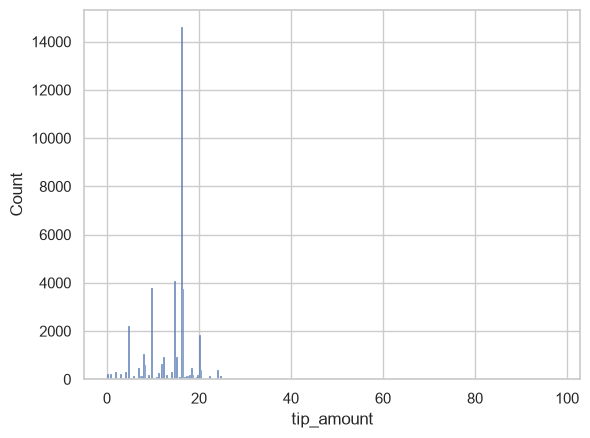

In [141]:
taxi=pd.read_csv(TAXI_URL)

#Inspecting the shape of the data
taxi.shape

taxi.head()
taxi.info()
taxi.describe()

taxi.isna().sum()

sns.histplot(data=taxi, x='tip_amount')



**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The shape of the data is a normal distibution with row entries of 41202 and columns of 13. There are no missing values neither are there impossible values.
The 'tip_amount' distribution is right skewed, with outliers and there are no zeros. So from this, preprocessing needs to be mindful of the skewed data


In [142]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi=taxi[(taxi['trip_distance']>0) & (taxi['fare_amount']>0)].copy()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare_per_mile']=taxi['fare_amount']/taxi['trip_distance']
#taxi['total_surcharges']=taxi['mta_tax']+taxi['tolls_amount']+taxi['improvement_surcharge']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder)
taxi=pd.get_dummies(taxi,columns=['VendorID','RatecodeID','payment_type','store_and_fwd_flag','PULocationID','DOLocationID'],drop_first=True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
taxi.shape

(41126, 270)

**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** 
1.I removed invalid rows in order to clean the data and ensure good learning by the agent and there were no missing values
2. I engineered the fare_by_mile feature because it plays a factor in influencing the tip, because the the longer the trip, the higher the fares. Passengers mostly decide the amount of tip base on the total fare of the ride
3.


In [143]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate features (X) and target (y = tip_amount)
x = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']


# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.20, random_state=RANDOM_STATE
)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

scaler=StandardScaler()
# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
#print(x_train.shape, x_val.shape, x_test.shape)

num_col=['trip_distance','fare_amount','passenger_count','mta_tax','tolls_amount','improvement_surcharge','fare_per_mile']
 
x_train[num_col]=scaler.fit_transform(x_train[num_col])

x_val[num_col]=scaler.transform(x_val[num_col])
x_test[num_col]=scaler.transform(x_test[num_col])

**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** The ratio used was 60:20:20
A separate validation set is useful in addition to the test set in order to compare the choices made by the agent as well as to adjust models to improve performance
The scalar must be fit on the training data only to prevent data leakage. This is done because if the scalar is fit on the validation or test data, the model would gain some knowledge on the data which it is supposed to predict. So to ensure an unbiased decision, the scalar is fit on just the training data.


RMSE for Training(Linear Regression): 4.7764 RMSE for Validation(Linear Regression):  5.0465 RMSE for Testing(Linear Regression):  5.0169
R2 score for Training(Linear Regression): 0.0624 R2 score for Validation(Linear Regression):  0.0451 R2 score for Testing(Linear Regression):  0.0496
RMSE for Training(Random Forest Regression): 2.8349 RMSE for Validation(Random Forest Regression):  5.6682 RMSE for Testing(Random Forest Regression):  5.6247
R2 score for Training(Random Forest Regression): 0.6697 R2 score for Validation(Random Forest Regression):  -0.2047 R2 score for Testing(Random Forest Regression):  -0.1946


Text(0.5, 1.0, 'Predicted vs Actual Tip Amount (Test Set)')

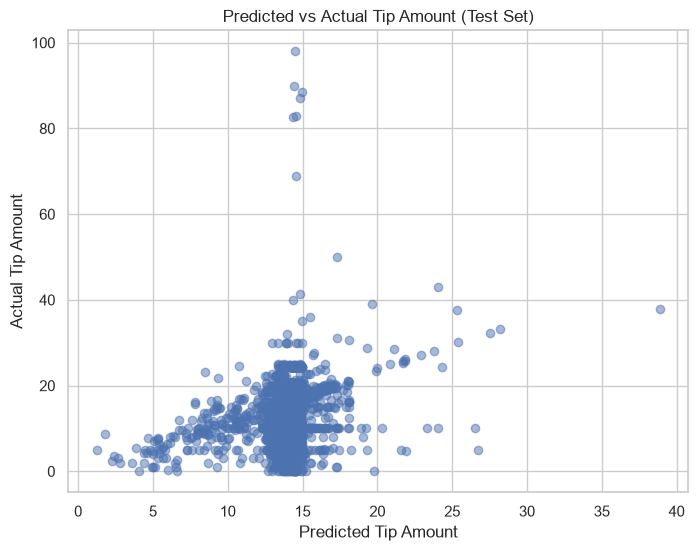

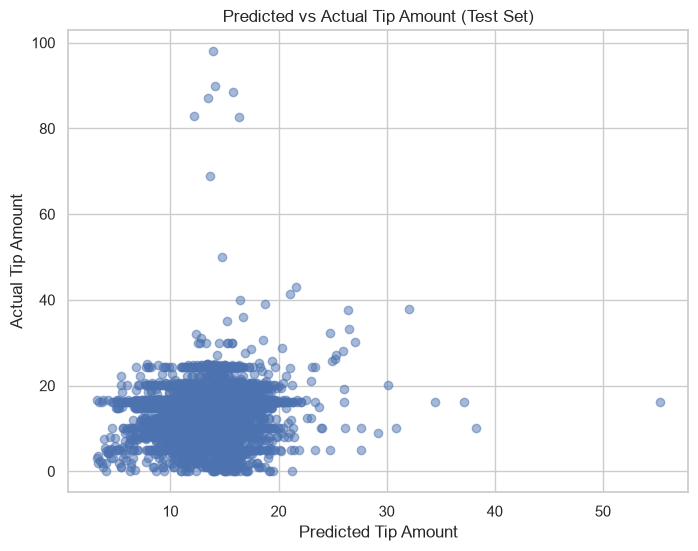

In [144]:
##PArt 1.4
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model2 = RandomForestRegressor()

lr_model.fit(x_train, y_train)
lr_model2.fit(x_train, y_train)


#Linear Regeression prediction values
y_train_pred = lr_model.predict(x_train)
y_val_pred = lr_model.predict(x_val)
y_test_pred = lr_model.predict(x_test) 

##Random Forest prediction vlues
y_train_pred2 = lr_model2.predict(x_train)
y_val_pred2 = lr_model2.predict(x_val)
y_test_pred2 = lr_model2.predict(x_test)

##Linear Regression RMSE and R^2 for all three sets
train_rmse = mean_squared_error(y_train,y_train_pred) **0.5
train_r2= r2_score(y_train,y_train_pred)
val_rmse = mean_squared_error(y_val,y_val_pred)**0.5
val_r2 = r2_score(y_val,y_val_pred)
test_rmse = mean_squared_error(y_test,y_test_pred)**0.5
test_r2= r2_score(y_test,y_test_pred)

##Ramdom Forest RMSE and R^2 for all three sets
train_rmse_2 = mean_squared_error(y_train,y_train_pred2) **0.5
train_r2_2= r2_score(y_train,y_train_pred2)
val_rmse_2=mean_squared_error(y_val,y_val_pred2)**0.5
val_r2_2=r2_score(y_val,y_val_pred2)
test_rmse_2=mean_squared_error(y_test,y_test_pred2)**0.5
test_r2_2=r2_score(y_test,y_test_pred2)

##Printing the values 
print("RMSE for Training(Linear Regression):",round(train_rmse,4),
      "RMSE for Validation(Linear Regression): ",round(val_rmse,4),
      "RMSE for Testing(Linear Regression): ",round(test_rmse,4))
print("R2 score for Training(Linear Regression):", round(train_r2,4),
      "R2 score for Validation(Linear Regression): ",round(val_r2,4),
      "R2 score for Testing(Linear Regression): ",round(test_r2,4))

print("RMSE for Training(Random Forest Regression):",round(train_rmse_2,4),
      "RMSE for Validation(Random Forest Regression): ",round(val_rmse_2,4),
      "RMSE for Testing(Random Forest Regression): ",round(test_rmse_2,4))
print("R2 score for Training(Random Forest Regression):", round(train_r2_2,4),
      "R2 score for Validation(Random Forest Regression): ",round(val_r2_2,4),
      "R2 score for Testing(Random Forest Regression): ",round(test_r2_2,4))



##Plotting the scatterplot for the Linear Regression Model
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, y_test, alpha=0.5)

plt.xlabel("Predicted Tip Amount")
plt.ylabel("Actual Tip Amount")
plt.title("Predicted vs Actual Tip Amount (Test Set)")

##Plotting the scatterplot for the Random Forest Regression Model
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred2, y_test, alpha=0.5)

plt.xlabel("Predicted Tip Amount")
plt.ylabel("Actual Tip Amount")
plt.title("Predicted vs Actual Tip Amount (Test Set)")

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** 
1. The Linear Regression Model performed best on the validation set because it had a lower RMSE value and higher R^2 value than those of the Random Forest's. This means that the Linear Regression model was able to generalise better. the hyper-parameters used was random state
2.-->The Linear Regression model is underfitting, this is because the values across the training, validation and testion for both RMSE and R^2 apper closer and approach the same values. So it is assumed the model didn't memorize the training set and so it is too simple.[RMSE for Training(Linear Regression): 4.78 RMSE for Validation(Linear Regression):  5.05 RMSE for Testing(Linear Regression):  5.02
R2 score for Training(Linear Regression): 0.06 R2 score for Validation(Linear Regression):  0.05 R2 score for Testing(Linear Regression):  0.05]
-->FOr the Random FOrest model, it is overfitting because there is a huge difference between the training and the validation set of the RMSE as well as that of the R^2. This entails that the model learned very well on the training data but failed to properly learn
[RMSE for Training(Random Forest Regression): 2.85 RMSE for Validation(Random Forest Regression):  5.64 RMSE for Testing(Random Forest Regression):  5.63
R2 score for Training(Random Forest Regression): 0.67 R2 score for Validation(Random Forest Regression):  -0.19 R2 score for Testing(Random Forest Regression):  -0.19]
3. In order to reduce overfitting,we need to make the model slightly less complex. By making use of more examples and instances in the training set, it will learn and figure out more genric patterns instead of memorizing

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


Text(0, 0.5, 'Number of Individuals')

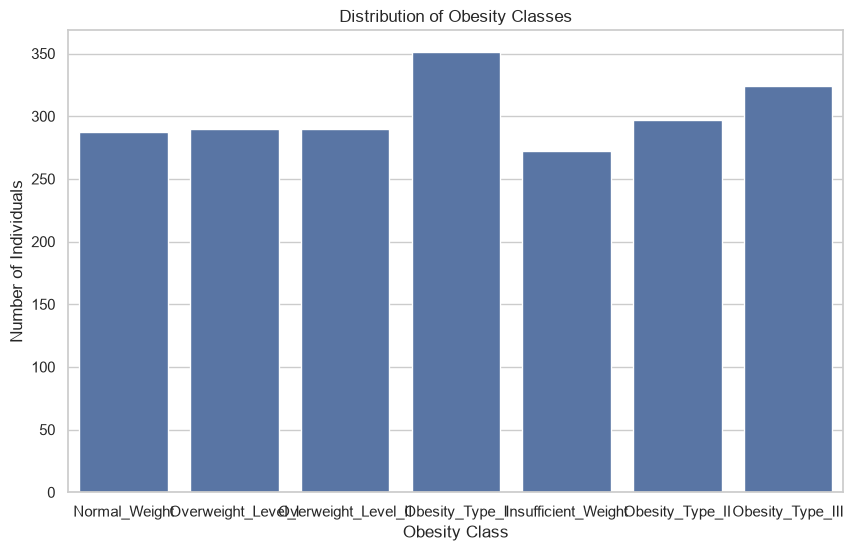

In [145]:
##Part 2.1
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
#Loading the obesity dataset
obesity=pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
#Displaying the number of rows and columns
#obesity.shape

#Display some rows in the dataset
#obesity.head()

#Display information about the dataset
# obesity.info()

#Displaying the statistics of the numerical features
# obesity.describe()

#Checking for missing values in every column
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
# Display the number of samples in each obesity class
print("================")

print(obesity["NObeyesdad"].value_counts())

print("================")
plt.figure(figsize=(10,6))
sns.countplot(data=obesity,x='NObeyesdad')

plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Class")
plt.ylabel("Number of Individuals")


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** There are 2111 rows/features. The categorical columns are Gender, family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad and the numerical columns are Age, Height,Weight, FCVC,NCP,CH2O,FAF,TUE.
The traget is balanced across the 7 classes and class imbalance matters for classification to check for bias within the dataset. If one class has a larger number of samples than others, the would be a bias towards that class and the agent could perform poorly in making predictions for the target

In [146]:
##Part 2.2
# TODO: Encode categorical columns.
from sklearn.preprocessing import LabelEncoder
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
bin_col=['family_history_with_overweight','FAVC','SMOKE','SCC']
for c in bin_col:
    obesity[c]=obesity[c].map({'yes':1,'no':0})

#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

ordinalish_col=['CAEC','CALC']
for oc in ordinalish_col:
    obesity[oc]=obesity[oc].map({'no':0,'Sometimes':1,'Frequently':2,'Always':3})

obesity=pd.get_dummies(obesity,columns=['Gender','MTRANS'],drop_first=True)

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

obesity['BMI']=obesity['Weight']/(obesity['Height']**2)

# TODO: Encode the target `NObeyesdad` into integer class labels
lEencoder=LabelEncoder()
obesity['NObeyesdad']=lEencoder.fit_transform(obesity['NObeyesdad'])
#   from sklearn.preprocessing import LabelEncoder

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** 1. I used binary encoding for columns:
family_history_with_overweight, FAVC, SMOKE, SCC, because they contain only two options/values[yes or no]. I used Ordinal Encoding for columns:CAEC, CALC, because the values which they have are in a particular arrangement or order. I used one-hot encoding for the columns: Gender,MTRANS because their values have no specific order. I used LabelEncoder for NObeyesdad to assign every class in obesity a specific integer label

2. I engineered the BMI feature because it does not influence NObeyesdad om any way, neither does it make use of it in its calculations. SO there would be no chances of data leakage
3. 


In [147]:
##Part 2.3
# TODO: Separate X (features) and y (encoded NObeyesdad).
x= obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scalar=StandardScaler()

num_col=['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','BMI']
 
x_train[num_col]=scalar.fit_transform(x_train[num_col])
x_val[num_col]=scalar.transform(x_val[num_col])
x_test[num_col]=scalar.transform(x_test[num_col])






**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** The split ratio used was 60:20:20. Stratify=y is important because it ensures that the proportion of each class in obesity in all the three sets are intact and equal. So if you split without stratifying, some classes proportions could be over or underrepresented than others, thereby increasing the sampling bias and resulting in an unfair evaluation


              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       0.93      0.72      0.82        58
           2       0.96      0.94      0.95        70
           3       0.95      1.00      0.98        60
           4       1.00      0.98      0.99        65
           5       0.72      0.81      0.76        58
           6       0.83      0.83      0.83        58

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.90      0.90      0.90       423

Accuracy for training set:  0.9281
Accuracy for validation set:  0.8839
Accuracy for testing set:  0.9007
The Macro F1 for the training set: 0.9258
The Macro F1 for the validation set: 0.8779
The Macro F1 for the testing set: 0.8972


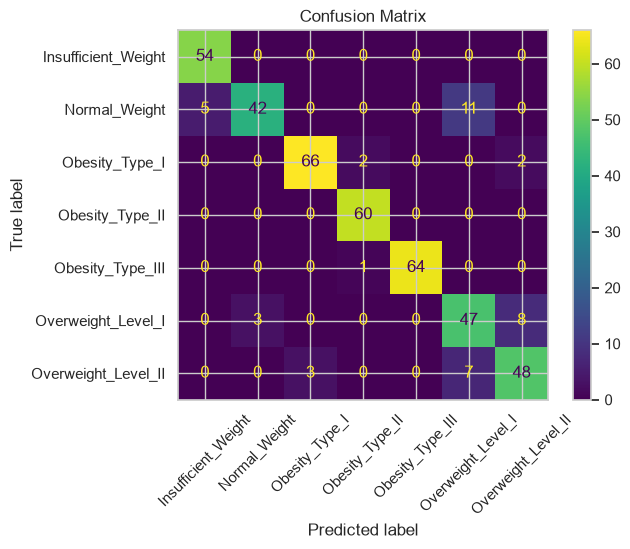

In [148]:
##Part 2.4
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,f1_score,classification_report)
from sklearn.metrics import ConfusionMatrixDisplay


LR_classifier=LogisticRegression(max_iter=1000)

LR_classifier.fit(x_train,y_train)
# TODO: Predict on train, validation, and test.

y_train_pred=LR_classifier.predict(x_train)
y_val_pred=LR_classifier.predict(x_val)
y_test_pred=LR_classifier.predict(x_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

y_train_pred_acc=accuracy_score(y_train,y_train_pred)
y_val_pred_acc=accuracy_score(y_val,y_val_pred)
y_test_pred_acc=accuracy_score(y_test,y_test_pred)

y_train_f1_score=f1_score(y_train,y_train_pred,average="macro")
y_val_f1_score=f1_score(y_val,y_val_pred,average="macro")
y_test_f1_score=f1_score(y_test,y_test_pred,average="macro")

print(classification_report(y_test,y_test_pred))

print('==============================')
print('Accuracy for training set: ',round(y_train_pred_acc,4))
print('Accuracy for validation set: ',round(y_val_pred_acc,4))
print('Accuracy for testing set: ',round(y_test_pred_acc,4))

print('==============================')


print('The Macro F1 for the training set:',round(y_train_f1_score,4))
print('The Macro F1 for the validation set:',round(y_val_f1_score,4))
print('The Macro F1 for the testing set:',round(y_test_f1_score,4))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred,display_labels=lEencoder.classes_,xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()
#   Which classes are most often confused?
##Normal Weight and Overweight Level I, Overweight Level I and Overweight Level II, Overweight Level II and Overweight Level I

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** 1. I chose the Logistics Regression because it's a simple classfier model for multiclass classification problems. It is also easy to interpret.
2. In comparing the training, validation and testing accracy, their values appear to be around the same value, their gap is small, meaning the model generalizes well.Their F1 values are also around the same value and so produces strong results. Therefore the model is well-fitted.
Accuracy for training set:  0.9281
Accuracy for validation set:  0.8839
Accuracy for testing set:  0.9007
==============================
The Macro F1 for the training set: 0.9258
The Macro F1 for the validation set: 0.8779
The Macro F1 for the testing set: 0.8972

3.From the confusion matrix, the biggest confusions are between Normal Weight and Overweight Level I, Overweight Level I and Overweight Level II, Overweight Level II and Overweight Level I. This is because these adjacent levels have some level of similarity between their characteristics which makes it hard for the model to differentiate between them.


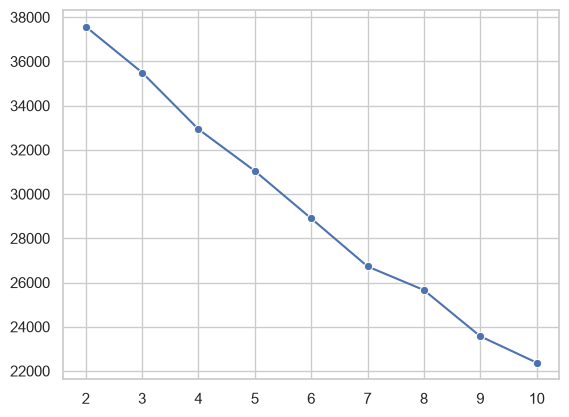

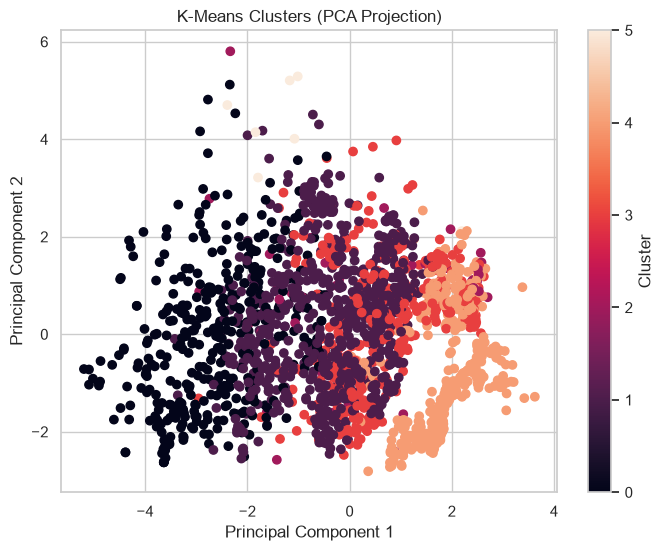

In [151]:
##SECTION 3
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_clus = obesity.drop(columns=["NObeyesdad"])

scaler = StandardScaler()
X_clus_scale = scaler.fit_transform(X_clus)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

inertia=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=RANDOM_STATE)

    kmeans.fit(X_clus_scale)
    inertia.append(kmeans.inertia_)

sns.lineplot(x=range(2,11),y=inertia,marker='o')

plt.show()
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k=6

kmeans=KMeans(n_clusters=chosen_k,random_state=RANDOM_STATE)
cluster_labels=kmeans.fit_predict(X_clus_scale)


# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(X_clus_scale)

plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=cluster_labels,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters (PCA Projection)")

plt.colorbar(label="Cluster")

plt.show()
#   (from sklearn.decomposition import PCA) and colour points by cluster.


In [152]:
# TODO: How well do the clusters line up with the TRUE obesity levels? 
# Build a crosstab of cluster label vs the real NObeyesdad category: 
# pd.crosstab(cluster_labels, obesity['NObeyesdad']) 
pd.crosstab(cluster_labels,obesity['NObeyesdad'])

#  Do some clusters map cleanly onto specific obesity levels?

NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,152,149,4,1,0,81,13
1,114,96,183,43,0,136,168
2,1,13,6,15,1,3,5
3,5,25,111,104,1,65,98
4,0,0,47,133,322,3,6
5,0,4,0,1,0,2,0


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** 1.I made evaluations of k values from 2 to 10, using the Elbow Methos, and the graph showed the decrease in inertia reduced drastically after k=6, insinuating that 6 clusters provides a good balance in clusters and model simplicity 

2. The clusters fairly resemble the real obesity levels, Cluster 4 maps well to one obesity category, however most of the other clusters contain a mixture of various obesity levels. This means that obesity levels sometimes share overlapping characteristics, which make it hard to differentiate, using this ML model

3.In a real public-health setting where labels are expensive to collect, these clusters would be useful when group individuals with similarities in their lifestyle, health and diets, when obesity labels are not available. It also aids in finding underlying patterms in the population of individuals and prioritise groups which require more assistance.



---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:** 1. The classifier learned the relationship between features and labels, because it was trained using data with labels. KMeans does not use obesity labels on the contrary, it grouped individuals based on similarities in their features, thereby discovering patterns in the data

2. The tip amount(target) was a continuous value , which was evaluated using the RMSE, used to measure prediction error and R^2 which measures the degree of variation in the target. For the categorical one, theperformance was evaluates using accuracy and macro F1 score, which measures how the model accurately classifies individuals into seven categories.

3. The biggest train-vs-test gap happened in the Random Forest Regression model because its training performance was way better than its validation and testing which results in overfitting. The most effective way to close it is to reduce how complex the model is to help it improve generalisation
